<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_3_The_Discrete_Fourier_Transform_(DFT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Euler's formula, complex exponentials, and the DFT synthesis/analysis equations.

The Project: Write a native DFT algorithm in pure NumPy, benchmark it against standard loops, and analyze a multi-tone signal.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

def dft_naive_loops(x):
    """Computes the DFT of a 1D signal using raw nested loops."""
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        sum_bin = 0.0 + 0.0j
        for n in range(N):
            exponent = -2j * np.pi * k * n / N
            sum_bin += x[n] * np.exp(exponent)
        X[k] = sum_bin
    return X

def dft_vectorized(x):
    """Computes the DFT using a vectorized matrix-vector dot product."""
    N = len(x)
    # Create rows (k) and columns (n) indices grids
    k = np.arange(N).reshape((N, 1))
    n = np.arange(N).reshape((1, N))

    # Generate the complete DFT matrix transformation grid
    W = np.exp(-2j * np.pi * k * n / N)

    # Execute a clean matrix dot product
    return np.dot(W, x)

Benchmarking with array size N = 250 samples...
Naive Loop DFT Time: 0.10246 seconds
Vectorized Matrix DFT Time: 0.01594 seconds
Speedup Factor: 6.4x faster!


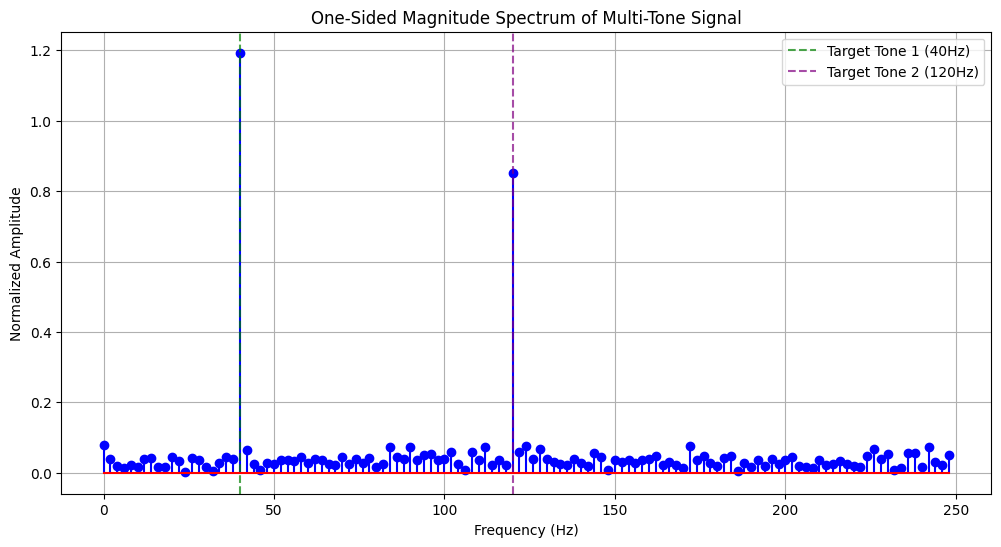

In [ ]:
# 1. Synthesize a Multi-Tone Signal
fs = 500                    # Sampling Frequency (Hz)
t = np.arange(0, 0.5, 1/fs) # 0.5 seconds duration (N = 250 samples)

# Multi-tone signal components
f1, amp1 = 40, 1.2
f2, amp2 = 120, 0.8
noise = np.random.normal(0, 0.3, len(t))

# Combine tones with random noise
signal_in = (amp1 * np.sin(2 * np.pi * f1 * t)) + (amp2 * np.sin(2 * np.pi * f2 * t)) + noise

# 2. Benchmark the Performance Differences
print(f"Benchmarking with array size N = {len(t)} samples...")

start = time.time()
X_loop = dft_naive_loops(signal_in)
loop_time = time.time() - start
print(f"Naive Loop DFT Time: {loop_time:.5f} seconds")

start = time.time()
X_vector = dft_vectorized(signal_in)
vector_time = time.time() - start
print(f"Vectorized Matrix DFT Time: {vector_time:.5f} seconds")
print(f"Speedup Factor: {loop_time / vector_time:.1f}x faster!")

# 3. Calculate Two-Sided vs One-Sided Magnitude Spectrums
N = len(t)
frequencies = np.arange(N) * (fs / N)

# Compute magnitude scale normalized to input sample length
magnitude = np.abs(X_vector) / N

# Isolate positive frequencies (One-Sided spectrum)
half_N = N // 2
pos_frequencies = frequencies[:half_N]
# Multiply by 2 to conserve energy from the discarded negative half frequencies
pos_magnitude = magnitude[:half_N] * 2

# 4. Graphical Spectrum Output Analysis
plt.figure(figsize=(12, 6))
plt.stem(pos_frequencies, pos_magnitude, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title("One-Sided Magnitude Spectrum of Multi-Tone Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.axvline(x=40, color='green', linestyle='--', alpha=0.7, label='Target Tone 1 (40Hz)')
plt.axvline(x=120, color='purple', linestyle='--', alpha=0.7, label='Target Tone 2 (120Hz)')
plt.grid(True)
plt.legend()
plt.show()